# 1. Criando seno de amplitude e frequência variável (Não linear)

A variação da amplitude e da frequência não segue uma progressão linear, sendo controlada por funções suaves, como exponenciais e funções trigonométricas:

$$
A_d(t) = a + b \cdot e^{-\frac{(t - \mu_d)^2}{\sigma_d^2}}, \quad
A_e(t) = a' + b' \cdot e^{-\frac{(t - \mu_e)^2}{\sigma_e^2}}
$$

$$
f_d(t) = f_0 + f_1 \cdot \sin\left( \frac{\pi t}{T} \right), \quad
f_e(t) = f_0 + f_1 \cdot \cos\left( \frac{\pi t}{T} \right)
$$

A frequência angular é obtida por:

$$
\omega_d(t) = 2 \pi f_d(t), \quad
\omega_e(t) = 2 \pi f_e(t)
$$

A fase é obtida pela integral da frequência angular:

$$
\phi_d(t) = \int_0^t \omega_d(\tau) \, d\tau, \quad
\phi_e(t) = \int_0^t \omega_e(\tau) \, d\tau
$$

Portanto, os sinais finais são:

$$
\varphi_d(t) = A_d(t) \cdot \sin(\phi_d(t)), \quad
\varphi_e(t) = A_e(t) \cdot \sin(\phi_e(t))
$$


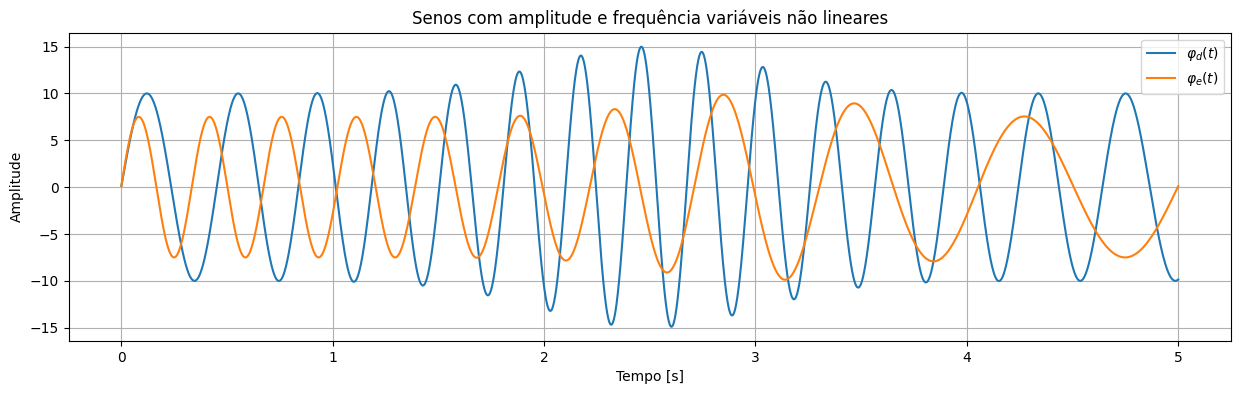

In [20]:
import numpy as np
import matplotlib.pyplot as plt



# 1. Tempo de simulação: 5 segundos, com 5000 pontos
t = np.linspace(0, 5, 5000)  # vetor de tempo de 0 a 5 s
dt = t[1] - t[0]             # passo de tempo entre os pontos (usado na integração)

# 2. Amplitude variável (não linear): cresce e depois diminui
# Aqui usamos uma função gaussiana para controlar a amplitude no tempo (tipo sino)
A_d = (2 + np.exp(-((t - 2.5)**2) / 0.5)  ) * 5  # pico no meio
A_e = (1.5 + 0.5 * np.exp(-((t - 3)**2) / 0.4) ) * 5

# 3. Frequência variável (não linear): sobe e depois desce com forma senoidal
f_d = 2 + 1.5 * np.sin(np.pi * t / 5)       # varia entre 0.5 e 3.5 Hz
f_e = 2 + np.cos(np.pi * t / 5)            # varia entre 1 e 3 Hz

# 4. Frequência angular (rad/s) = 2π * f(t)
omega_d = 2 * np.pi * f_d
omega_e = 2 * np.pi * f_e

# 5. Integração da frequência → fase(t) = ∫ω(t) dt ≈ soma acumulada * dt
fase_d = np.cumsum(omega_d) * dt
fase_e = np.cumsum(omega_e) * dt

# 6. Sinais finais com amplitude e frequência variando
phi_d = A_d * np.sin(fase_d)
phi_e = A_e * np.sin(fase_e)

# 7. Plot dos sinais
plt.figure(figsize=(15, 4))
plt.plot(t, phi_d, label=r'$\varphi_d(t)$')
plt.plot(t, phi_e, label=r'$\varphi_e(t)$')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude')
plt.title(r'Senos com amplitude e frequência variáveis não lineares')
plt.grid(True)
plt.legend()
plt.show()

# 2. Resolvendo o sistema dinâmico usando método de Euler

$$ \begin{bmatrix}
\dot{x}_a \\
\dot{y}_a \\
\dot{\theta}
\end{bmatrix}
= 

\frac{R}{2} \cdot
\begin{bmatrix}
\cos \theta & \cos \theta \\
\sin \theta & \sin \theta \\
\frac{1}{L} & -\frac{1}{L}
\end{bmatrix}

\cdot

\begin{bmatrix}
\varphi_D \\
\varphi_E
\end{bmatrix}
$$

In [21]:
# Constantes do sistema
R = 0.034  # raio da roda [m]
L = 0.147/2  # distância entre rodas [m]

# Estados: [x, y, theta]
x = np.zeros_like(t)
y = np.zeros_like(t)
theta = np.zeros_like(t)

# Integração via método de Euler
for i in range(1, len(t)):
    dt = t[i] - t[i-1]
    th = theta[i-1]

    v = (R / 2) * (phi_d[i-1] + phi_e[i-1])
    w = (R / (2 * L)) * (phi_d[i-1] - phi_e[i-1])

    x[i] = x[i-1] + v * np.cos(th) * dt
    y[i] = y[i-1] + v * np.sin(th) * dt
    theta[i] = theta[i-1] + w * dt


# 3. Plotando a trajetória do robô

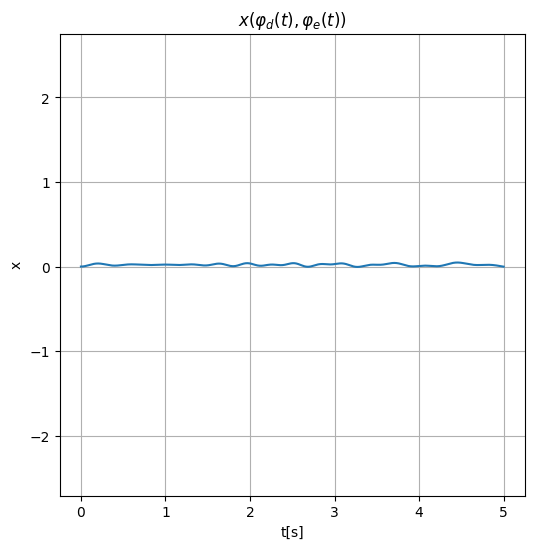

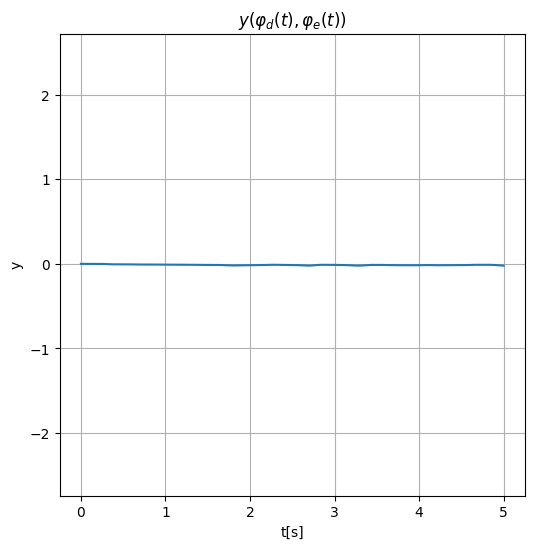

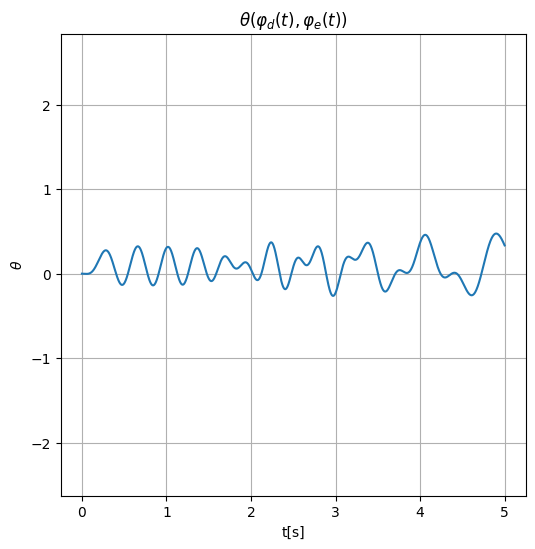

In [22]:

plt.figure(figsize=(6,6))
plt.plot(t, x)
plt.xlabel('t[s]')
plt.ylabel('x')
plt.title(r'$x(\varphi_d(t), \varphi_e(t))$')
plt.axis('equal')
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.plot(t, y)
plt.xlabel('t[s]')
plt.ylabel('y')
plt.title(r'$y(\varphi_d(t), \varphi_e(t))$')
plt.axis('equal')
plt.grid(True)
plt.show()


plt.figure(figsize=(6,6))
plt.plot(t, theta)
plt.xlabel('t[s]')
plt.ylabel(r'$\theta$')
plt.title(r'$\theta(\varphi_d(t), \varphi_e(t))$')
plt.axis('equal')
plt.grid(True)
plt.show()


In [23]:
import pandas as pd

# Criar DataFrame com os dados simulados
df = pd.DataFrame({
    'tempo_s': t,
    'phi_d': phi_d,
    'phi_e': phi_e,
    'x_m': x,
    'y_m': y,
    'theta_rad': theta
})

# Exibir as primeiras linhas do DataFrame
display(df.head())

# Salvar em CSV
df.to_csv('NonLinearData.csv', index=False)

,tempo_s,phi_d,phi_e,x_m,y_m,theta_rad
0,0.000000,0.125686,0.141392,0.000000,0.000000e+00,0.000000
1,0.001000,0.251411,0.282733,0.000005,0.000000e+00,-0.000004
2,0.002000,0.377156,0.423974,0.000014,-3.299914e-11,-0.000011
3,0.003001,0.502900,0.565064,0.000027,-1.811968e-10,-0.000022
4,0.004001,0.628623,0.705953,0.000045,-5.754325e-10,-0.000036
